# 08 Results Visualisation

This notebook creates final result graphs and summary tables for the dissertation.

It visualises:

- Model performance on training/test data
- Model performance on recent unused June data
- MAE, RMSE, and R² across prediction horizons
- Predicted vs actual dissolved oxygen
- Recent forecast outputs
- Live prediction outputs

These figures can be used in the Results and Discussion chapters.


Cell 1 — Markdown
Cell 2 — Imports
Cell 3 — File Paths
Cell 4 — Load Results Files
Cell 5 — Best Model Performance Table
Cell 6 — Recent Unused Data Performance Table
Cell 7 — Prepare Horizon Order
Cell 8 — RMSE by Horizon: Original Test Set
Cell 9 — MAE by Horizon: Original Test Set
Cell 10 — R² by Horizon: Original Test Set
Cell 11 — RMSE by Horizon: Recent Unused Data
Cell 12 — Predicted vs Actual: Recent DO mg/L 60min
Cell 13 — Predicted vs Actual: Recent DO % 60min
Cell 14 — Recent Time-Series Plot: DO mg/L 60min
Cell 15 — Recent Time-Series Plot: DO % 60min
Cell 16 — Live Forecast Preview
Cell 17 — Recent Forecast Preview
Cell 18 — Save Summary Tables
Cell 19 — Summary

In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
PERFORMANCE_FILE = "../data/processed/do_prediction_model_performance.csv"
RECENT_PERFORMANCE_FILE = "../data/processed/recent_data_model_performance.csv"
ALL_PREDICTIONS_FILE = "../data/processed/all_model_predictions.csv"
RECENT_PREDICTIONS_FILE = "../data/processed/recent_data_predictions.csv"
LIVE_FORECAST_FILE = "../data/processed/live_river_do_forecasts.csv"
RECENT_FORECAST_FILE = "../data/processed/recent_river_do_forecasts.csv"

FIGURES_DIR = "../figures/results"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [51]:
performance = pd.read_csv(PERFORMANCE_FILE)
recent_performance = pd.read_csv(RECENT_PERFORMANCE_FILE)
all_predictions = pd.read_csv(ALL_PREDICTIONS_FILE, parse_dates=["timestamp"])
recent_predictions = pd.read_csv(RECENT_PREDICTIONS_FILE, parse_dates=["timestamp"])
live_forecasts = pd.read_csv(LIVE_FORECAST_FILE)
recent_forecasts = pd.read_csv(RECENT_FORECAST_FILE)

print("Performance:", performance.shape)
print("Recent performance:", recent_performance.shape)
print("All predictions:", all_predictions.shape)
print("Recent predictions:", recent_predictions.shape)
print("Live forecasts:", live_forecasts.shape)
print("Recent forecasts:", recent_forecasts.shape)

Performance: (48, 9)
Recent performance: (16, 7)
All predictions: (1036440, 13)
Recent predictions: (136872, 16)
Live forecasts: (147, 27)
Recent forecasts: (8565, 27)


In [52]:
best_models = (
    performance.sort_values("RMSE")
    .groupby(["target_type", "horizon"])
    .head(1)
    .reset_index(drop=True)
)

best_models

,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
0,DO mg/L,15min,do_mgl_next_15min,Linear Regression,0.059432,0.142753,0.994124,86376,21595
1,DO mg/L,30min,do_mgl_next_30min,Linear Regression,0.085146,0.200089,0.988456,86374,21594
2,DO mg/L,45min,do_mgl_next_45min,Linear Regression,0.108538,0.247535,0.982333,86372,21593
3,DO mg/L,60min,do_mgl_next_60min,Linear Regression,0.129906,0.282753,0.976948,86369,21593
4,DO mg/L,75min,do_mgl_next_75min,Linear Regression,0.152506,0.334699,0.967701,86367,21592
5,DO mg/L,90min,do_mgl_next_90min,Linear Regression,0.174986,0.388585,0.956464,86364,21592
6,DO mg/L,105min,do_mgl_next_105min,Linear Regression,0.195606,0.427643,0.947274,86362,21591
7,DO mg/L,120min,do_mgl_next_120min,Linear Regression,0.214726,0.456126,0.940018,86360,21590
8,DO %,15min,do_pct_next_15min,Linear Regression,0.486125,1.264440,0.991258,86376,21595
9,DO %,30min,do_pct_next_30min,Linear Regression,0.708503,1.815417,0.981980,86374,21594


In [53]:
recent_performance

,target_type,horizon,model_used,MAE,RMSE,R2,rows_evaluated
0,DO mg/L,15min,Linear Regression,0.077644,0.212255,0.989967,8565
1,DO %,15min,Linear Regression,0.715133,2.079814,0.986470,8565
2,DO mg/L,30min,Linear Regression,0.130677,0.341960,0.973950,8562
3,DO %,30min,Linear Regression,1.209420,3.310916,0.965697,8562
4,DO mg/L,45min,Linear Regression,0.175175,0.451072,0.954658,8559
5,DO %,45min,Linear Regression,1.642805,4.363029,0.940407,8559
6,DO mg/L,60min,Linear Regression,0.206918,0.512395,0.941473,8556
7,DO %,60min,Linear Regression,1.958530,4.912268,0.924429,8556
8,DO mg/L,75min,Linear Regression,0.246817,0.618201,0.914776,8553
9,DO %,75min,Linear Regression,2.354719,5.898358,0.890998,8553


In [54]:
horizon_order = ["15min", "30min", "45min", "60min", "75min", "90min", "105min", "120min"]
horizon_minutes = {
    "15min": 15,
    "30min": 30,
    "45min": 45,
    "60min": 60,
    "75min": 75,
    "90min": 90,
    "105min": 105,
    "120min": 120,
}

best_models["horizon_minutes"] = best_models["horizon"].map(horizon_minutes)
recent_performance["horizon_minutes"] = recent_performance["horizon"].map(horizon_minutes)

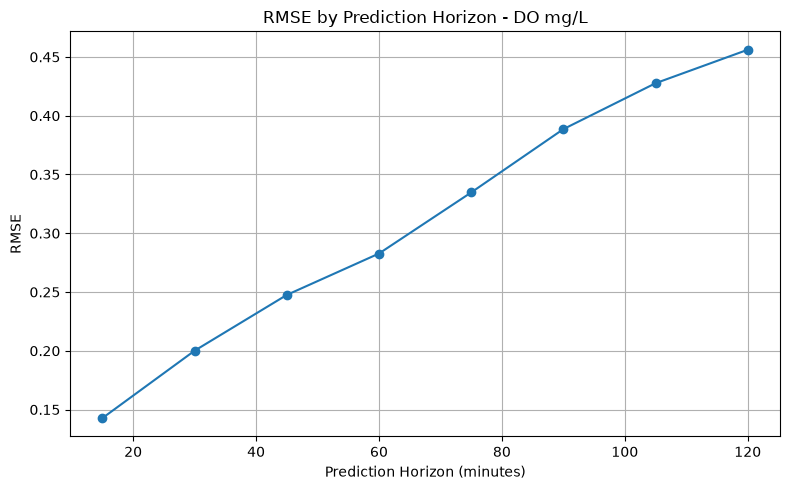

Saved: ../figures/results\rmse_by_horizon_DO_mg_L.png


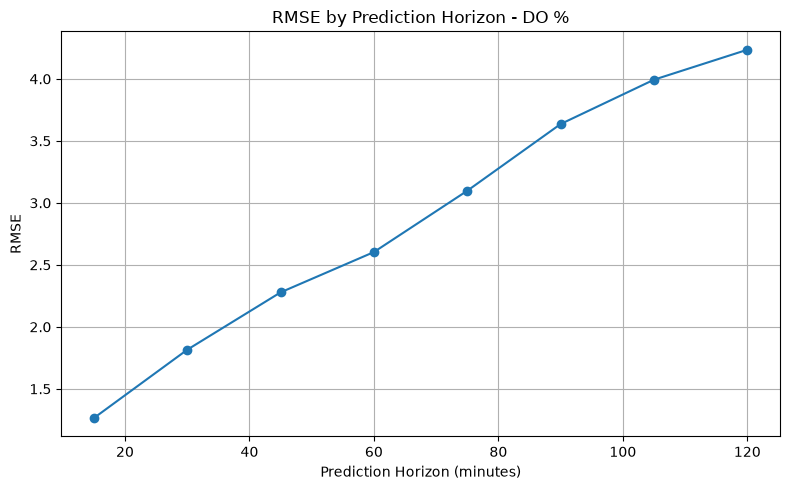

Saved: ../figures/results\rmse_by_horizon_DO_pct.png


In [55]:
for target in best_models["target_type"].unique():
    temp = best_models[best_models["target_type"] == target].sort_values("horizon_minutes")

    safe_target = (
        target.replace(" ", "_")
              .replace("/", "_")
              .replace("%", "pct")
    )

    plt.figure(figsize=(8, 5))
    plt.plot(temp["horizon_minutes"], temp["RMSE"], marker="o")
    plt.xlabel("Prediction Horizon (minutes)")
    plt.ylabel("RMSE")
    plt.title(f"RMSE by Prediction Horizon - {target}")
    plt.grid(True)
    plt.tight_layout()

    output_path = os.path.join(FIGURES_DIR, f"rmse_by_horizon_{safe_target}.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Saved:", output_path)

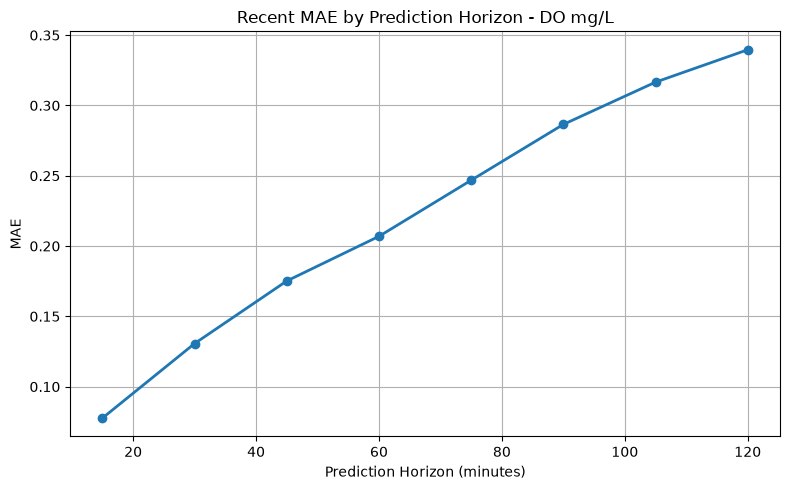

Saved: ../figures/results\recent_mae_by_horizon_DO_mg_L.png


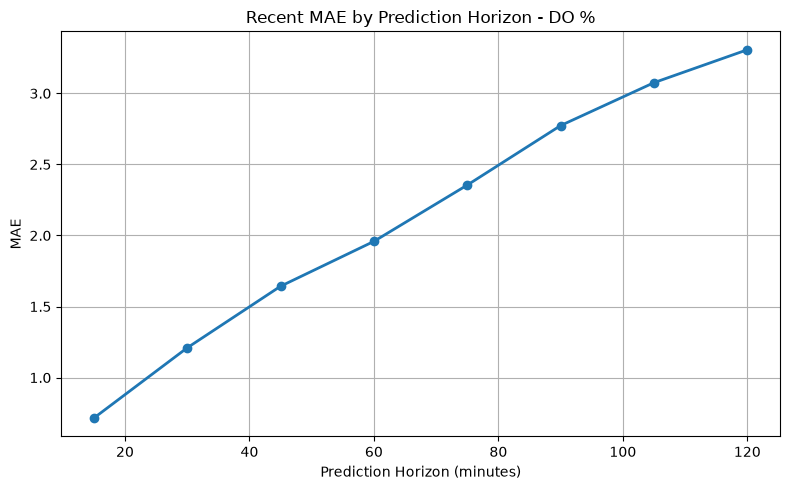

Saved: ../figures/results\recent_mae_by_horizon_DO_pct.png


In [56]:
for target in recent_performance["target_type"].unique():

    temp = recent_performance[
        recent_performance["target_type"] == target
    ].sort_values("horizon_minutes")

    safe_target = (
        target.replace(" ", "_")
              .replace("/", "_")
              .replace("%", "pct")
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        temp["horizon_minutes"],
        temp["MAE"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Prediction Horizon (minutes)")
    plt.ylabel("MAE")
    plt.title(f"Recent MAE by Prediction Horizon - {target}")

    plt.grid(True)
    plt.tight_layout()

    output_path = os.path.join(
        FIGURES_DIR,
        f"recent_mae_by_horizon_{safe_target}.png"
    )

    plt.savefig(output_path, dpi=300)

    plt.show()

    print("Saved:", output_path)

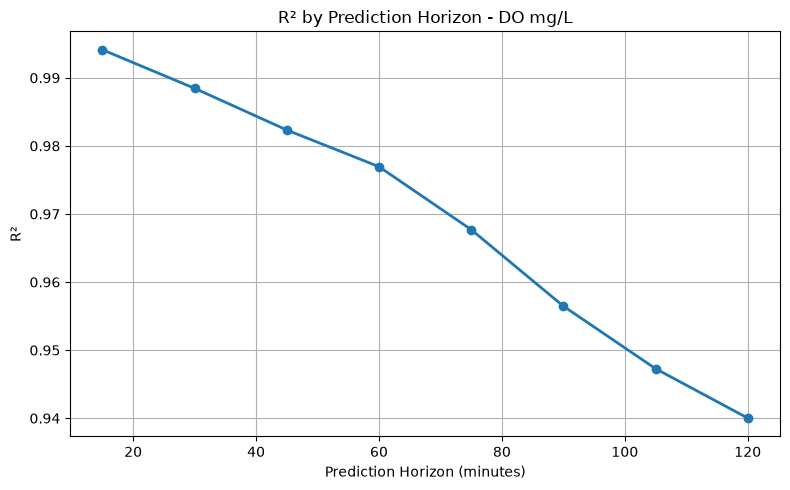

Saved: ../figures/results\r2_by_horizon_DO_mg_L.png


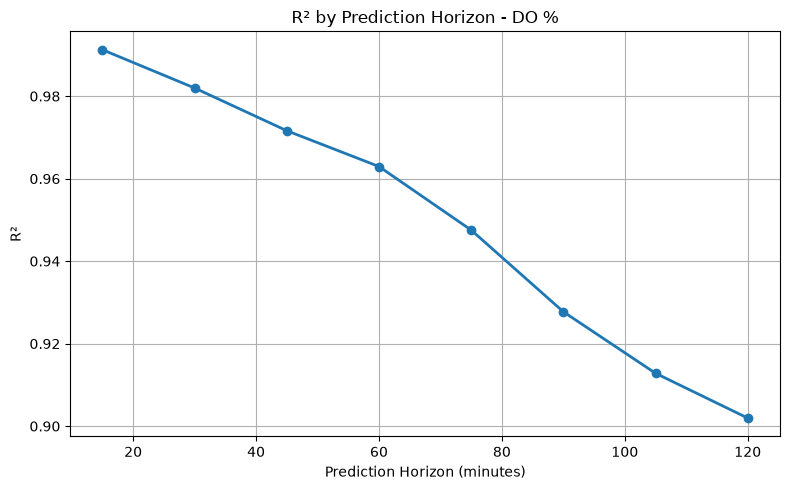

Saved: ../figures/results\r2_by_horizon_DO_pct.png


In [57]:
for target in best_models["target_type"].unique():

    temp = best_models[
        best_models["target_type"] == target
    ].sort_values("horizon_minutes")

    # Safe filename
    safe_target = (
        target.replace(" ", "_")
              .replace("/", "_")
              .replace("%", "pct")
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        temp["horizon_minutes"],
        temp["R2"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Prediction Horizon (minutes)")
    plt.ylabel("R²")
    plt.title(f"R² by Prediction Horizon - {target}")

    plt.grid(True)

    plt.tight_layout()

    output_path = os.path.join(
        FIGURES_DIR,
        f"r2_by_horizon_{safe_target}.png"
    )

    plt.savefig(output_path, dpi=300)

    plt.show()

    print("Saved:", output_path)

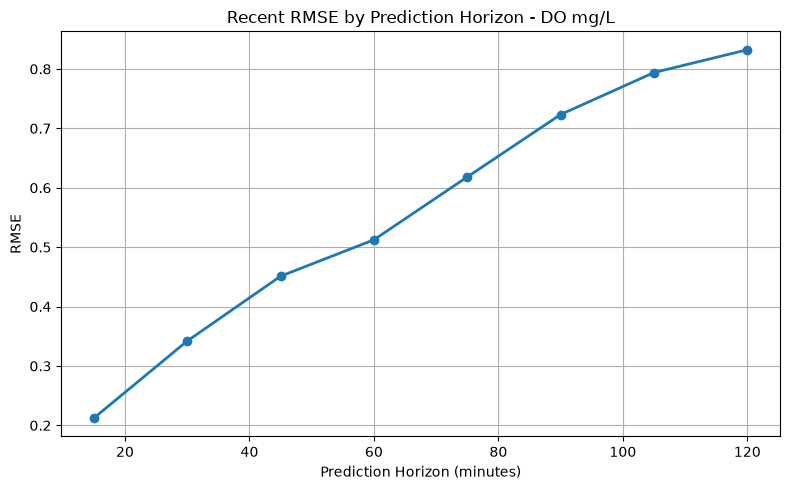

Saved: ../figures/results\recent_rmse_by_horizon_DO_mg_L.png


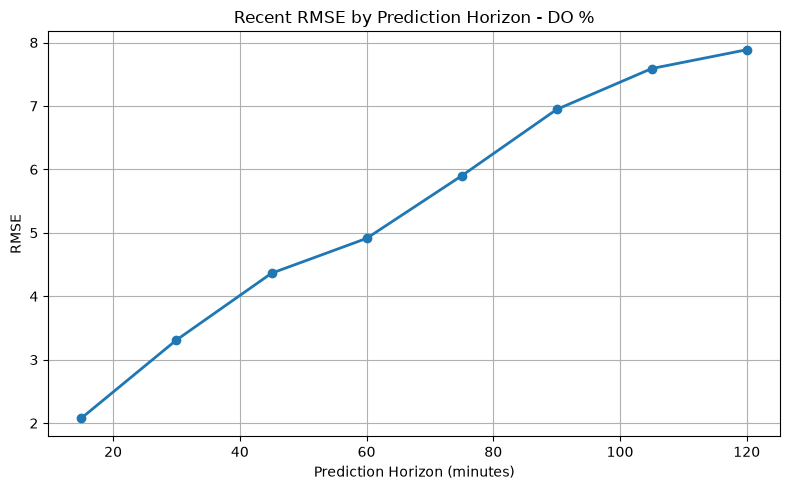

Saved: ../figures/results\recent_rmse_by_horizon_DO_pct.png


In [58]:
for target in recent_performance["target_type"].unique():

    temp = recent_performance[
        recent_performance["target_type"] == target
    ].sort_values("horizon_minutes")

    safe_target = (
        target.replace(" ", "_")
              .replace("/", "_")
              .replace("%", "pct")
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        temp["horizon_minutes"],
        temp["RMSE"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Prediction Horizon (minutes)")
    plt.ylabel("RMSE")
    plt.title(f"Recent RMSE by Prediction Horizon - {target}")

    plt.grid(True)
    plt.tight_layout()

    output_path = os.path.join(
        FIGURES_DIR,
        f"recent_rmse_by_horizon_{safe_target}.png"
    )

    plt.savefig(output_path, dpi=300)

    plt.show()

    print("Saved:", output_path)

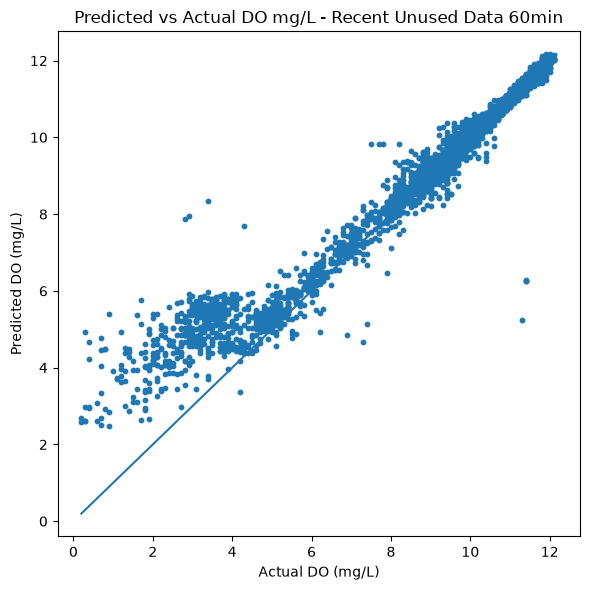

Saved: ../figures/results\predicted_vs_actual_recent_do_mgl_60min.png


In [59]:
recent_mgl_60 = recent_predictions[
    (recent_predictions["target_type"] == "DO mg/L") &
    (recent_predictions["horizon"] == "60min")
].copy()

plt.figure(figsize=(6, 6))
plt.scatter(recent_mgl_60["actual_value"], recent_mgl_60["predicted_value"], s=10)
plt.xlabel("Actual DO (mg/L)")
plt.ylabel("Predicted DO (mg/L)")
plt.title("Predicted vs Actual DO mg/L - Recent Unused Data 60min")

min_val = min(recent_mgl_60["actual_value"].min(), recent_mgl_60["predicted_value"].min())
max_val = max(recent_mgl_60["actual_value"].max(), recent_mgl_60["predicted_value"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, "predicted_vs_actual_recent_do_mgl_60min.png")
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

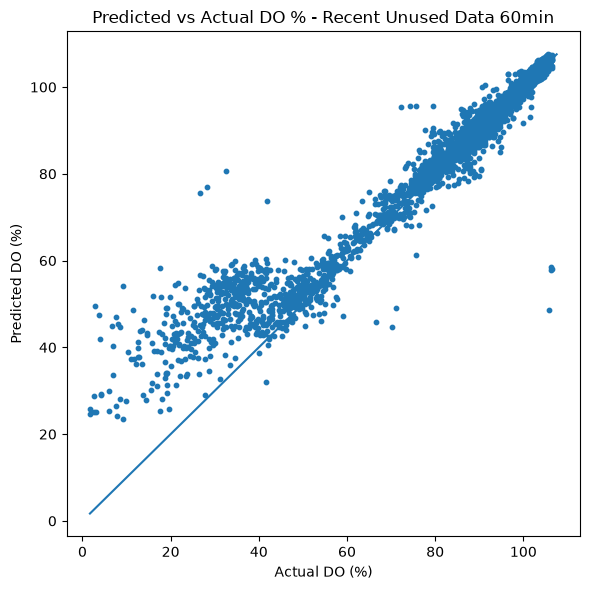

Saved: ../figures/results\predicted_vs_actual_recent_do_pct_60min.png


In [60]:
recent_pct_60 = recent_predictions[
    (recent_predictions["target_type"] == "DO %") &
    (recent_predictions["horizon"] == "60min")
].copy()

plt.figure(figsize=(6, 6))
plt.scatter(recent_pct_60["actual_value"], recent_pct_60["predicted_value"], s=10)
plt.xlabel("Actual DO (%)")
plt.ylabel("Predicted DO (%)")
plt.title("Predicted vs Actual DO % - Recent Unused Data 60min")

min_val = min(recent_pct_60["actual_value"].min(), recent_pct_60["predicted_value"].min())
max_val = max(recent_pct_60["actual_value"].max(), recent_pct_60["predicted_value"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, "predicted_vs_actual_recent_do_pct_60min.png")
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

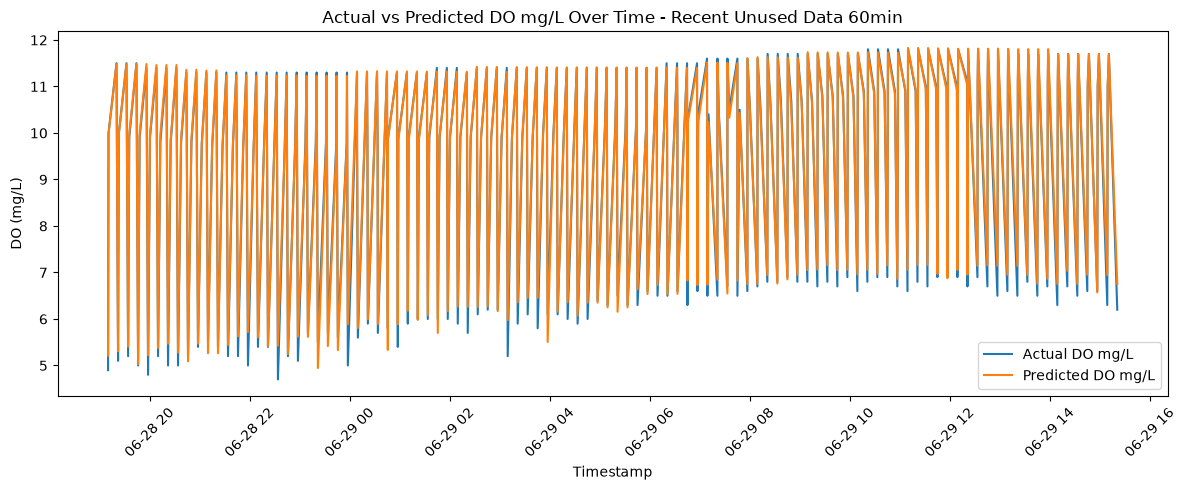

Saved: ../figures/results\timeseries_actual_vs_predicted_recent_do_mgl_60min.png


In [61]:
recent_mgl_60 = recent_mgl_60.sort_values("timestamp")

sample = recent_mgl_60.tail(300)

plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["actual_value"], label="Actual DO mg/L")
plt.plot(sample["timestamp"], sample["predicted_value"], label="Predicted DO mg/L")
plt.xlabel("Timestamp")
plt.ylabel("DO (mg/L)")
plt.title("Actual vs Predicted DO mg/L Over Time - Recent Unused Data 60min")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, "timeseries_actual_vs_predicted_recent_do_mgl_60min.png")
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

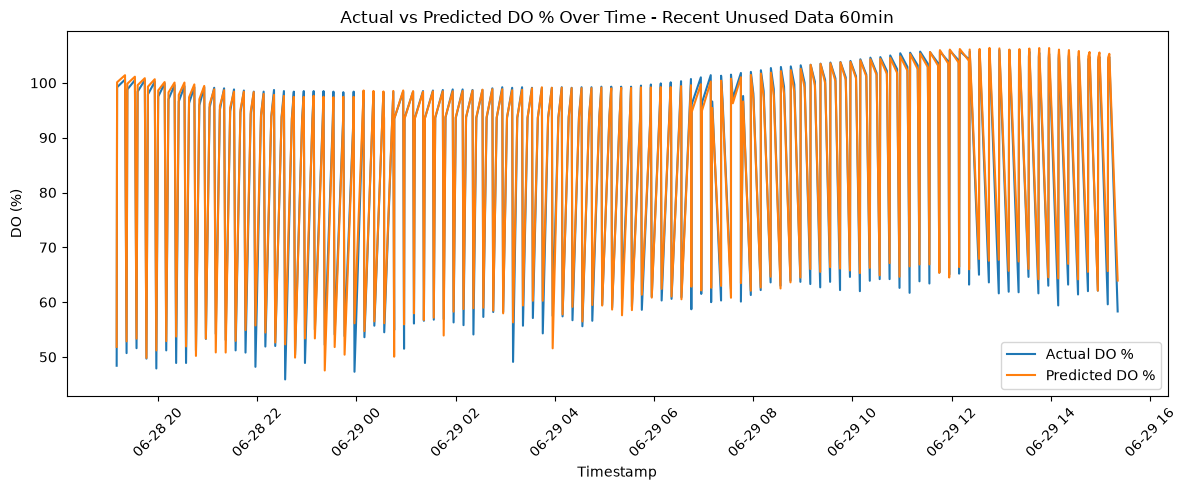

Saved: ../figures/results\timeseries_actual_vs_predicted_recent_do_pct_60min.png


In [62]:
recent_pct_60 = recent_pct_60.sort_values("timestamp")

sample = recent_pct_60.tail(300)

plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["actual_value"], label="Actual DO %")
plt.plot(sample["timestamp"], sample["predicted_value"], label="Predicted DO %")
plt.xlabel("Timestamp")
plt.ylabel("DO (%)")
plt.title("Actual vs Predicted DO % Over Time - Recent Unused Data 60min")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, "timeseries_actual_vs_predicted_recent_do_pct_60min.png")
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved:", output_path)

In [63]:
live_forecasts.tail()

,prediction_run_time,latest_sensor_timestamp,sensor_id,sensor_name,current_do_mgl,current_do_pct,pollution_alert,anomaly_type,predicted_do_mgl_15min,predicted_do_pct_15min,...,predicted_do_pct_75min,predicted_do_mgl_90min,predicted_do_pct_90min,predicted_do_mgl_105min,predicted_do_pct_105min,predicted_do_mgl_120min,predicted_do_pct_120min,air_temperature_c,sunshine_wm2,cloud_cover_pct
142,2026-06-29 15:32:35,2026-06-04 21:09:04,941115,Derwent 13-50,9.9,92.1,0,0,9.904924,92.193378,...,92.569194,9.941272,92.652017,9.947786,92.728665,9.954785,92.805130,19.5,434.0,100.0
143,2026-06-29 15:32:35,2026-06-04 21:13:40,sensor022,Derwent 13,5.5,51.5,0,0,5.549587,52.063612,...,54.613760,5.913980,55.303623,5.991636,56.011879,6.072682,56.756533,19.5,434.0,100.0
144,2026-07-07 16:35:49,2026-06-01 05:30:34,941205,Derwent 21,11.2,95.8,0,0,11.217626,96.038545,...,97.118062,11.305997,97.378287,11.322432,97.630371,11.339697,97.884818,20.5,420.0,70.0
145,2026-07-07 16:35:49,2026-06-04 21:09:04,941115,Derwent 13-50,9.9,92.1,0,0,9.902995,92.172918,...,92.506461,9.936314,92.584342,9.942610,92.657975,9.949579,92.734487,20.5,420.0,70.0
146,2026-07-07 16:35:49,2026-06-04 21:13:40,sensor022,Derwent 13,5.5,51.5,0,0,5.547659,52.043151,...,54.551027,5.909022,55.235948,5.986460,55.941190,6.067476,56.685890,20.5,420.0,70.0


In [64]:
recent_forecasts.head()

,prediction_run_time,latest_sensor_timestamp,sensor_id,sensor_name,current_do_mgl,current_do_pct,pollution_alert,anomaly_type,predicted_do_mgl_15min,predicted_do_pct_15min,...,predicted_do_pct_75min,predicted_do_mgl_90min,predicted_do_pct_90min,predicted_do_mgl_105min,predicted_do_pct_105min,predicted_do_mgl_120min,predicted_do_pct_120min,air_temperature_c,sunshine_wm2,cloud_cover_pct
0,2026-06-29 17:09:01,2026-06-04 23:49:59,sensor022,Derwent 13,5.1,47.5,0,0,5.138914,47.797382,...,49.484507,5.460779,50.023734,5.537037,50.608885,5.618371,51.252950,10.9,0.0,96
1,2026-06-29 17:09:01,2026-06-05 00:01:58,sensor022,Derwent 13,4.9,45.0,0,0,4.966454,45.640871,...,48.644708,5.436481,49.504066,5.540172,50.406752,5.648096,51.365475,10.2,0.0,91
2,2026-06-29 17:09:01,2026-06-05 00:08:43,941115,Derwent 13-50,9.6,89.0,0,0,9.618495,89.111483,...,89.714567,9.723088,89.908311,9.748413,90.119393,9.775181,90.347730,10.2,0.0,91
3,2026-06-29 17:09:01,2026-06-05 00:13:57,sensor022,Derwent 13,5.0,46.0,0,0,5.065615,46.619873,...,49.554134,5.523026,50.396526,5.624443,51.282010,5.730225,52.223282,10.2,0.0,91
4,2026-06-29 17:09:01,2026-06-05 00:20:42,941115,Derwent 13-50,9.6,88.9,0,0,9.618746,89.008746,...,89.613473,9.722408,89.808857,9.747747,90.021837,9.774640,90.252579,10.2,0.0,91


In [65]:
best_models_output = "../data/processed/best_model_summary_for_dissertation.csv"
recent_performance_output = "../data/processed/recent_unused_data_summary_for_dissertation.csv"

best_models.to_csv(best_models_output, index=False)
recent_performance.to_csv(recent_performance_output, index=False)

print("Saved:", best_models_output)
print("Saved:", recent_performance_output)

Saved: ../data/processed/best_model_summary_for_dissertation.csv
Saved: ../data/processed/recent_unused_data_summary_for_dissertation.csv


## Summary

This notebook generated final visualisations and summary tables for the dissertation.

The visualisations include:

- RMSE, MAE, and R² across prediction horizons
- Recent unused-data RMSE across horizons
- Predicted vs actual plots
- Actual vs predicted time-series plots
- Live prediction output preview
- Recent unused-data prediction output preview

The figures were saved to:

`figures/results/`

These figures can be used in the Results and Discussion chapters of the dissertation.